# CPC353 Natural Language Processing
## Assignment 2: Stock Trend Prediction with News Sentiment
### Part 2: Stock Trend Prediction with LSTM

This notebook applies and extends the codes from Lab 4 (LSTM Classifier) to:
1. Load pre-trained GloVe word embeddings (glove-wiki-gigaword-50)
2. Build an LSTM classifier following Lab 4 architecture
3. Handle OOV (Out-of-Vocabulary) words
4. Evaluate using accuracy, precision, recall, and F1

## 1. Import Libraries (Lab 4 Step 2)

In [36]:
# Install required packages (Lab 4 Step 2)
# pip install tensorflow gensim nltk scikit-learn

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras (Lab 4)
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Gensim for loading pre-trained GloVe (Lab 4 Step 5)
import gensim.downloader as downloader

# NLTK TweetTokenizer (Lab 4 Step 6)
from nltk.tokenize import TweetTokenizer

# Sklearn for evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.1


## 2. Set Parameters (Lab 4 Step 4)

In [38]:
# Parameters (Lab 4 Step 4)
sentence_length = 50   # Max sequence length (Lab 4 used 15 for short sentences)
n_embedding = 50       # GloVe dimension (glove-wiki-gigaword-50)
n_output = 3           # 3 classes: downtrend, flat, uptrend
batch_size = 64        # Batch size for training

print("Parameters (following Lab 4 Step 4):")
print(f"  sentence_length = {sentence_length}")
print(f"  n_embedding = {n_embedding}")
print(f"  n_output = {n_output}")
print(f"  batch_size = {batch_size}")

Parameters (following Lab 4 Step 4):
  sentence_length = 50
  n_embedding = 50
  n_output = 3
  batch_size = 64


## 3. Load Pre-trained GloVe (Lab 4 Step 5)

Load the pre-trained word embedding model "glove-wiki-gigaword-50" using gensim.

In [40]:
# Load pre-trained GloVe (Lab 4 Step 5)
print("Loading pre-trained GloVe (glove-wiki-gigaword-50)...")
print("This may take a few minutes on first run.")

model_glove = downloader.load("glove-wiki-gigaword-50")

print(f"\nGloVe loaded successfully!")
print(f"Vocabulary size: {len(model_glove)}")
print(f"Embedding dimension: {model_glove.vector_size}")

Loading pre-trained GloVe (glove-wiki-gigaword-50)...
This may take a few minutes on first run.

GloVe loaded successfully!
Vocabulary size: 400000
Embedding dimension: 50


In [41]:
# Test GloVe embeddings
print("\n" + "="*60)
print("Sample GloVe vectors:")
print("="*60)
test_words = ['stock', 'market', 'price', 'company', 'profit']
for i, word in enumerate(test_words):
    if word in model_glove:
        vec = model_glove[word]
        print(f"{i+1}. '{word}': [{vec[0]:.4f}, {vec[1]:.4f}, {vec[2]:.4f}, ...]")


Sample GloVe vectors:
1. 'stock': [-0.0743, -0.7784, 0.4934, ...]
2. 'market': [-0.0093, -0.7279, 0.4683, ...]
3. 'price': [-0.4495, 0.1178, 0.6507, ...]
4. 'company': [0.6258, -0.5770, 0.4116, ...]
5. 'profit': [0.4450, -0.8400, 1.2510, ...]


## 4. Initialize Tokenizer (Lab 4 Step 6)

In [43]:
# Create TweetTokenizer instance (Lab 4 Step 6)
tokenizer_nltk = TweetTokenizer()

print("TweetTokenizer initialized (Lab 4 Step 6)")

TweetTokenizer initialized (Lab 4 Step 6)


## 5. Load and Prepare Dataset

In [45]:
# Load dataset
df = pd.read_csv(r"stock_trend.csv")

# Calculate price change and assign trend labels
df['Price_Change_Percent'] = ((df['After'] - df['Before']) / df['Before']) * 100

def assign_trend(change_percent):
    if change_percent > 10:
        return 'uptrend'
    elif change_percent < -10:
        return 'downtrend'
    else:
        return 'flat'

df['Trend'] = df['Price_Change_Percent'].apply(assign_trend)

print("Dataset loaded!")
print(f"Total samples: {len(df)}")
print(f"\nTrend Distribution:")
print(df['Trend'].value_counts())
print("\n" + "="*60)
print("First 10 rows:")
print("="*60)
df[['Title', 'Trend']].head(10)

Dataset loaded!
Total samples: 24388

Trend Distribution:
Trend
flat         22626
uptrend       1232
downtrend      530
Name: count, dtype: int64

First 10 rows:


,Title,Trend
0,100 startups participate in Maxis' Market Acce...,flat
1,16.89% stake in Subur Tiasa traded off-market,flat
2,Najib wanted 1MDB's Genting Sanyen deal sped u...,flat
3,"25bps OPR cut likely in 2H20, says Manulife",flat
4,A 25-month extension on concession pushes Phar...,flat
5,3.7% of Yong Tai transacted off-market,flat
6,"3A, Ruberex, Thriven, Kanger, UniWall",flat
7,40% stake in IWH-CREC may cost Ekovest RM1.5b,flat
8,4.41% Kronologi Asia shares traded off-market,flat
9,4.96% of MMAG traded off market,flat


## 6. Text Preprocessing (Lab 4 Steps 7-8)

Normalize to lowercase and tokenize using TweetTokenizer.

In [47]:
def preprocess_and_tokenize(text):
    """Lab 4 Steps 7-8: Normalize and tokenize."""
    text = text.lower()  # Step 7: Normalize to lowercase
    tokens = tokenizer_nltk.tokenize(text)  # Step 8: Tokenize
    return tokens

# Apply preprocessing
df['Tokens'] = df['Title'].apply(preprocess_and_tokenize)

print("Text preprocessing completed (Lab 4 Steps 7-8)!")
print("\n" + "="*60)
print("First 10 rows after tokenization:")
print("="*60)
for i in range(10):
    print(f"{i+1}. Original: {df['Title'].iloc[i][:50]}...")
    print(f"   Tokens:   {df['Tokens'].iloc[i][:8]}...")
    print()

Text preprocessing completed (Lab 4 Steps 7-8)!

First 10 rows after tokenization:
1. Original: 100 startups participate in Maxis' Market Access D...
   Tokens:   ['100', 'startups', 'participate', 'in', 'maxis', "'", 'market', 'access']...

2. Original: 16.89% stake in Subur Tiasa traded off-market...
   Tokens:   ['16.89', '%', 'stake', 'in', 'subur', 'tiasa', 'traded', 'off-market']...

3. Original: Najib wanted 1MDB's Genting Sanyen deal sped up on...
   Tokens:   ['najib', 'wanted', '1mdb', "'", 's', 'genting', 'sanyen', 'deal']...

4. Original: 25bps OPR cut likely in 2H20, says Manulife...
   Tokens:   ['25bps', 'opr', 'cut', 'likely', 'in', '2h20', ',', 'says']...

5. Original: A 25-month extension on concession pushes Pharmani...
   Tokens:   ['a', '25', '-', 'month', 'extension', 'on', 'concession', 'pushes']...

6. Original: 3.7% of Yong Tai transacted off-market...
   Tokens:   ['3.7', '%', 'of', 'yong', 'tai', 'transacted', 'off-market']...

7. Original: 3A, Ruberex, Thriv

## 7. Split Data

In [49]:
# Prepare labels
label_mapping = {'downtrend': 0, 'flat': 1, 'uptrend': 2}
reverse_mapping = {0: 'downtrend', 1: 'flat', 2: 'uptrend'}

X = df['Tokens'].values
y = np.array([label_mapping[t] for t in df['Trend'].values])

# Split: 70% train, 20% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp)

print("Data split completed!")
print(f"  Training:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\n" + "="*60)
print("First 10 training samples:")
print("="*60)
for i in range(10):
    print(f"{i+1}. {X_train[i][:6]}... -> {reverse_mapping[y_train[i]]}")

Data split completed!
  Training:   17071 (70.0%)
  Validation: 4880 (20.0%)
  Test:       2437 (10.0%)

First 10 training samples:
1. ['uem', 'sunrise', '2q', 'net', 'profit', 'up']... -> flat
2. ['myanmar', 'ops', 'to', 'boost', 'daibochi', '’']... -> flat
3. ['public', 'bank', ',', 'hong', 'leong', 'bank']... -> flat
4. ['asia', 'bioenergy', 'sells', 'entire', 'stake', 'in']... -> flat
5. ['power', 'root', 'may', 'rebound', 'further', ',']... -> flat
6. ['bat', 'malaysia', ',', 'sapura', 'energy', ',']... -> flat
7. ['irb', 'claims', 'rm182', '.', '8m', 'in']... -> flat
8. ['cgs-cimb', 'research', 'lowers', 'target', 'price', 'for']... -> flat
9. ['metrod', '1q', 'net', 'profit', 'up', '12']... -> flat
10. ['public', 'bank', 'falls', '1.8', '%', 'to']... -> flat


## 8. Convert Tokens to Word Embedding Vectors (Lab 4 Step 9)

Convert tokens to vectors using model_glove[tokens].

**OOV Handling:** Words not in GloVe vocabulary use a zero vector or average vector.

In [51]:
# Calculate average embedding for OOV handling
# Using average of common words as OOV vector
common_words = ['the', 'a', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has']
oov_vector = np.mean([model_glove[w] for w in common_words if w in model_glove], axis=0)

def tokens_to_vectors(tokens, model, oov_vec):
    """
    Convert tokens to word embedding vectors (Lab 4 Step 9).
    
    OOV Handling: 
    - Words in GloVe: use the embedding vector
    - Words NOT in GloVe (OOV): use average embedding vector
    """
    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])
        else:
            # OOV handling: use average embedding
            vectors.append(oov_vec)
    return np.array(vectors) if vectors else np.array([oov_vec])

# Convert all data to vectors (Lab 4 Step 9-10)
print("Converting tokens to vectors (Lab 4 Step 9)...")
X_train_vecs = [tokens_to_vectors(t, model_glove, oov_vector) for t in X_train]
X_val_vecs = [tokens_to_vectors(t, model_glove, oov_vector) for t in X_val]
X_test_vecs = [tokens_to_vectors(t, model_glove, oov_vector) for t in X_test]

print("Conversion completed!")

# Count OOV words
oov_count = 0
total_count = 0
oov_examples = []
for tokens in X_train:
    for t in tokens:
        total_count += 1
        if t not in model_glove:
            oov_count += 1
            if len(oov_examples) < 10:
                oov_examples.append(t)

print(f"\nOOV Statistics (Training set):")
print(f"  Total tokens: {total_count}")
print(f"  OOV tokens: {oov_count} ({oov_count/total_count*100:.2f}%)")
print(f"  OOV examples: {oov_examples}")
print(f"  OOV handling: Average embedding vector")

Converting tokens to vectors (Lab 4 Step 9)...
Conversion completed!

OOV Statistics (Training set):
  Total tokens: 257980
  OOV tokens: 29318 (11.36%)
  OOV examples: ['daibochi', 'fy18', 'cgs-cimb', 'texchem', 'permaju', 'yi-lai', 'ralco', 'rm182', 'cgs-cimb', 'metrod']
  OOV handling: Average embedding vector


In [52]:
print("\n" + "="*60)
print("First 10 samples converted to vectors:")
print("="*60)
for i in range(10):
    print(f"{i+1}. Shape: {X_train_vecs[i].shape}, First: [{X_train_vecs[i][0][0]:.3f}, {X_train_vecs[i][0][1]:.3f}, ...]")


First 10 samples converted to vectors:
1. Shape: (13, 50), First: [0.181, -0.488, ...]
2. Shape: (9, 50), First: [-0.518, -0.005, ...]
3. Shape: (14, 50), First: [0.034, 0.506, ...]
4. Shape: (12, 50), First: [0.563, 0.359, ...]
5. Shape: (10, 50), First: [0.046, 0.061, ...]
6. Shape: (24, 50), First: [-0.525, -0.777, ...]
7. Shape: (11, 50), First: [-0.955, -0.123, ...]
8. Shape: (11, 50), First: [0.637, -0.084, ...]
9. Shape: (10, 50), First: [0.637, -0.084, ...]
10. Shape: (10, 50), First: [0.034, 0.506, ...]


## 9. Pad Sequences (Lab 4 Step 11)

In [54]:
def pad_vector_sequences(vector_list, maxlen, embedding_dim):
    """Pad sequences to fixed length (Lab 4 Step 11)."""
    padded = np.zeros((len(vector_list), maxlen, embedding_dim))
    for i, vecs in enumerate(vector_list):
        length = min(len(vecs), maxlen)
        padded[i, :length] = vecs[:length]
    return padded

# Pad sequences (Lab 4 Step 11)
X_train_pad = pad_vector_sequences(X_train_vecs, sentence_length, n_embedding)
X_val_pad = pad_vector_sequences(X_val_vecs, sentence_length, n_embedding)
X_test_pad = pad_vector_sequences(X_test_vecs, sentence_length, n_embedding)

# Print shape (Lab 4 Step 12)
print("Padded sequences (Lab 4 Steps 11-12):")
print(f"  X_train shape: {X_train_pad.shape}")
print(f"  X_val shape:   {X_val_pad.shape}")
print(f"  X_test shape:  {X_test_pad.shape}")

print("\n" + "="*60)
print("First 10 padded sequences:")
print("="*60)
for i in range(10):
    print(f"{i+1}. Shape: {X_train_pad[i].shape}")

Padded sequences (Lab 4 Steps 11-12):
  X_train shape: (17071, 50, 50)
  X_val shape:   (4880, 50, 50)
  X_test shape:  (2437, 50, 50)

First 10 padded sequences:
1. Shape: (50, 50)
2. Shape: (50, 50)
3. Shape: (50, 50)
4. Shape: (50, 50)
5. Shape: (50, 50)
6. Shape: (50, 50)
7. Shape: (50, 50)
8. Shape: (50, 50)
9. Shape: (50, 50)
10. Shape: (50, 50)


## 10. Prepare Labels

In [56]:
# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=n_output)
y_val_cat = to_categorical(y_val, num_classes=n_output)
y_test_cat = to_categorical(y_test, num_classes=n_output)

print("Labels converted to categorical:")
print(f"  y_train: {y_train_cat.shape}")
print(f"  y_val:   {y_val_cat.shape}")
print(f"  y_test:  {y_test_cat.shape}")

print("\n" + "="*60)
print("First 10 labels:")
print("="*60)
for i in range(10):
    print(f"{i+1}. {y_train_cat[i]} -> {reverse_mapping[y_train[i]]}")

Labels converted to categorical:
  y_train: (17071, 3)
  y_val:   (4880, 3)
  y_test:  (2437, 3)

First 10 labels:
1. [0. 1. 0.] -> flat
2. [0. 1. 0.] -> flat
3. [0. 1. 0.] -> flat
4. [0. 1. 0.] -> flat
5. [0. 1. 0.] -> flat
6. [0. 1. 0.] -> flat
7. [0. 1. 0.] -> flat
8. [0. 1. 0.] -> flat
9. [0. 1. 0.] -> flat
10. [0. 1. 0.] -> flat


## 11. Build LSTM Model (Lab 4 Step 13)

Following Lab 4's architecture using Keras Functional API.

In [58]:
# Build model following Lab 4 Step 13

# a. inputs = Input(shape=(sentence_length, n_embedding))
inputs = Input(shape=(sentence_length, n_embedding))

# b. lstm = LSTM(units, return_sequences=True, return_state=True)
lstm = LSTM(64, return_sequences=True, return_state=True)

# c. outputs_seq, state_h, state_c = lstm(inputs)
outputs_seq, state_h, state_c = lstm(inputs)

# d. flat = Flatten()(outputs_seq)
flat = Flatten()(outputs_seq)

# Add dropout for regularization
drop = Dropout(0.3)(flat)

# e. outputs = Dense(n_output, activation='softmax')(flat)
outputs = Dense(n_output, activation='softmax')(drop)

# f. model = Model(inputs=inputs, outputs=outputs)
model = Model(inputs=inputs, outputs=outputs)

# Compile with adam optimizer (Lab 4 Step 14)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("LSTM Model (Lab 4 Step 13):")
print("="*60)
model.summary()

LSTM Model (Lab 4 Step 13):


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ [(None, 50, 64),       │        29,440 │
│                                 │ (None, 64), (None,     │               │
│                                 │ 64)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         9,603 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,043 (152.51 KB)

 Trainable params: 39,043 (152.51 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train Model (Lab 4 Step 14)

In [60]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary format {0: weight, 1: weight, 2: weight}
# This is the format Keras expects
class_weights_dict = dict(enumerate(weights))

print("Class Weights Calculated:", class_weights_dict)

# 0: downtrend, 1: flat, 2: uptrend

Class Weights Calculated: {0: 15.337825696316262, 1: 0.3592835795765459, 2: 6.601314771848415}


In [61]:
# Training (Lab 4 Step 14: adam optimizer, epoch=20)
epochs = 20

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

print(f"Training (Lab 4 Step 14): optimizer='adam', epochs={epochs}, batch_size={batch_size}")
print("="*60)

history = model.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    class_weight=class_weights_dict,
    verbose=1
)

print("\nTraining completed!")



Training (Lab 4 Step 14): optimizer='adam', epochs=20, batch_size=64
Epoch 1/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5396 - loss: 1.0713 - val_accuracy: 0.3713 - val_loss: 1.1306
Epoch 2/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5570 - loss: 1.0024 - val_accuracy: 0.4717 - val_loss: 1.0673
Epoch 3/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5674 - loss: 0.9432 - val_accuracy: 0.4695 - val_loss: 1.0584
Epoch 4/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5767 - loss: 0.8826 - val_accuracy: 0.4947 - val_loss: 1.0177
Epoch 5/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - accuracy: 0.5886 - loss: 0.8247 - val_accuracy: 0.5068 - val_loss: 1.0033
Epoch 6/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6021 - loss: 0.7760 - val_accuracy: 0.4684 - val_loss: 1.0599
Epoch 7/20
267/267 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6177 - loss: 0.7122 - val_accuracy: 0.5627 - val_loss: 0.9216
Epoch 8/20
267/267 ━━━━

## 13. Training History Visualization

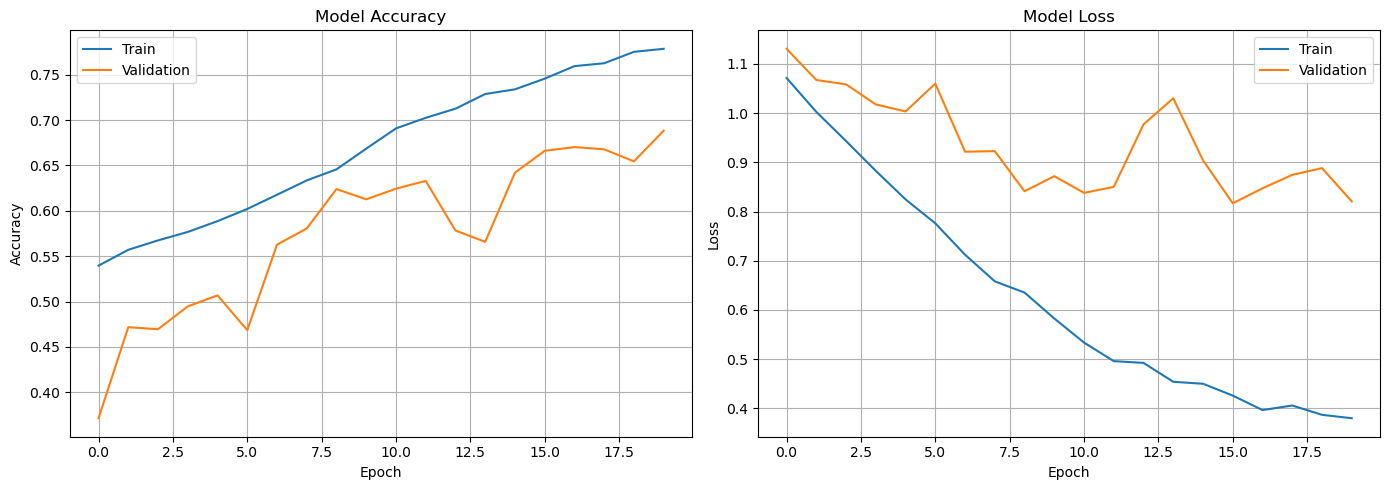

Training history saved to: lstm_training_history.png


In [63]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()

print("Training history saved to: lstm_training_history.png")

## 14. Model Evaluation (Lab 4 Step 15)

Evaluate using accuracy, precision, recall and F1.

In [65]:
# Predictions (Lab 4 Step 15: Testing)
y_pred_proba = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_proba, axis=1)

print("="*60)
print("TEST SET EVALUATION")
print("="*60)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f} (macro)")
print(f"Recall:    {recall:.4f} (macro)")
print(f"F1 Score:  {f1:.4f} (macro)")

77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
TEST SET EVALUATION

Accuracy:  0.6570
Precision: 0.3676 (macro)
Recall:    0.4563 (macro)
F1 Score:  0.3450 (macro)


In [66]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred,
                            target_names=['downtrend', 'flat', 'uptrend']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   downtrend       0.04      0.28      0.07        53
        flat       0.96      0.68      0.79      2261
     uptrend       0.11      0.41      0.17       123

    accuracy                           0.66      2437
   macro avg       0.37      0.46      0.34      2437
weighted avg       0.89      0.66      0.75      2437



CONFUSION MATRIX
[[  15   21   17]
 [ 317 1536  408]
 [  22   51   50]]


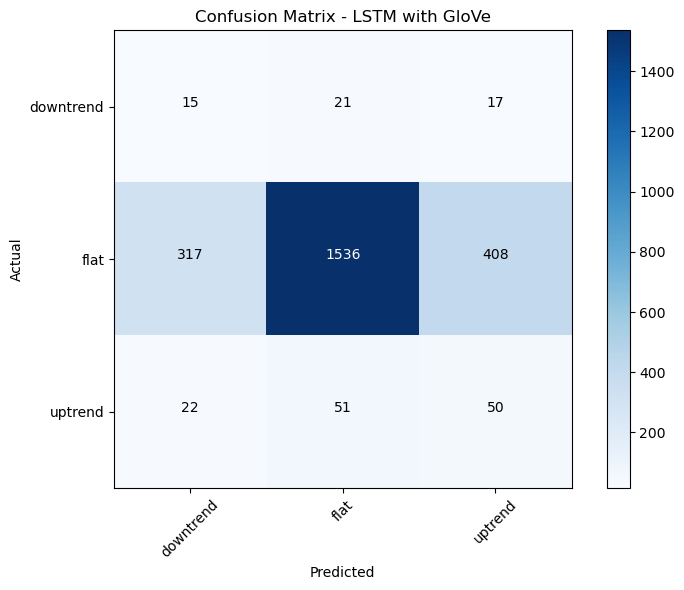

Confusion matrix saved to: lstm_confusion_matrix.png


In [67]:
print("="*60)
print("CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title('Confusion Matrix - LSTM with GloVe')
plt.colorbar()
labels = ['downtrend', 'flat', 'uptrend']
plt.xticks([0,1,2], labels, rotation=45)
plt.yticks([0,1,2], labels)
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i,j], ha='center', color=color)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

print("Confusion matrix saved to: lstm_confusion_matrix.png")

## 15. Sample Predictions

In [69]:
print("="*60)
print("SAMPLE PREDICTIONS (First 10 test samples)")
print("="*60)
for i in range(10):
    actual = reverse_mapping[y_test[i]]
    predicted = reverse_mapping[y_pred[i]]
    mark = "CORRECT" if actual == predicted else "WRONG"
    tokens_str = ' '.join(X_test[i][:8])
    print(f"\n{i+1}. {tokens_str}...")
    print(f"   Actual: {actual:10s} | Predicted: {predicted:10s} | {mark}")

SAMPLE PREDICTIONS (First 10 test samples)

1. eco world international completes stage one of uk...
   Actual: flat       | Predicted: flat       | CORRECT

2. property market to recover in coming years ,...
   Actual: flat       | Predicted: flat       | CORRECT

3. ghl systems 4q net profit up 11.5 %...
   Actual: flat       | Predicted: flat       | CORRECT

4. azrb , diversified gateway , formosa prosonic ,...
   Actual: flat       | Predicted: downtrend  | WRONG

5. messrs cas malaysia resigns as external auditor of...
   Actual: flat       | Predicted: flat       | CORRECT

6. public bank 3q net profit at rm1 ....
   Actual: flat       | Predicted: flat       | CORRECT

7. luster industries proposes diversification into property , construction...
   Actual: flat       | Predicted: flat       | CORRECT

8. ewein active , rises 7.04 % on tabung...
   Actual: uptrend    | Predicted: flat       | WRONG

9. midf upgrades maxis to ' neutral ' ,...
   Actual: flat       | Predicted: fla

## 16. OOV Handling Demonstration

In [71]:
print("="*60)
print("OOV (Out-of-Vocabulary) HANDLING DEMONSTRATION")
print("="*60)

print("\nOOV Handling Strategy:")
print("-"*40)
print("1. Check if word exists in GloVe vocabulary")
print("2. If YES: use model_glove[word] (Lab 4 Step 9)")
print("3. If NO (OOV): use average embedding vector")
print(f"\nGloVe vocabulary size: {len(model_glove)}")

# Test with different sentences
test_texts = [
    "company reports strong quarterly profit",
    "maybank share price increases significantly",
    "xyzrandom unknownword gibberish qwerty"
]

print("\n" + "="*60)
print("Testing OOV Handling:")
print("="*60)

for text in test_texts:
    tokens = tokenizer_nltk.tokenize(text.lower())
    
    # Check OOV
    in_vocab = [t for t in tokens if t in model_glove]
    oov = [t for t in tokens if t not in model_glove]
    
    # Convert and predict
    vecs = tokens_to_vectors(tokens, model_glove, oov_vector)
    padded = pad_vector_sequences([vecs], sentence_length, n_embedding)
    pred = model.predict(padded, verbose=0)
    pred_class = reverse_mapping[np.argmax(pred)]
    
    print(f"\nText: '{text}'")
    print(f"  Tokens: {tokens}")
    print(f"  In GloVe: {in_vocab}")
    print(f"  OOV (using avg): {oov if oov else 'None'}")
    print(f"  Prediction: {pred_class}")

OOV (Out-of-Vocabulary) HANDLING DEMONSTRATION

OOV Handling Strategy:
----------------------------------------
1. Check if word exists in GloVe vocabulary
2. If YES: use model_glove[word] (Lab 4 Step 9)
3. If NO (OOV): use average embedding vector

GloVe vocabulary size: 400000

Testing OOV Handling:

Text: 'company reports strong quarterly profit'
  Tokens: ['company', 'reports', 'strong', 'quarterly', 'profit']
  In GloVe: ['company', 'reports', 'strong', 'quarterly', 'profit']
  OOV (using avg): None
  Prediction: flat

Text: 'maybank share price increases significantly'
  Tokens: ['maybank', 'share', 'price', 'increases', 'significantly']
  In GloVe: ['maybank', 'share', 'price', 'increases', 'significantly']
  OOV (using avg): None
  Prediction: flat

Text: 'xyzrandom unknownword gibberish qwerty'
  Tokens: ['xyzrandom', 'unknownword', 'gibberish', 'qwerty']
  In GloVe: ['gibberish', 'qwerty']
  OOV (using avg): ['xyzrandom', 'unknownword']
  Prediction: flat


## 17. Summary

In [73]:
print("="*60)
print("PART 2 SUMMARY")
print("="*60)

print("\n1. GloVe EMBEDDING (Lab 4 Step 5):")
print(f"   - Model: glove-wiki-gigaword-50 (pre-trained)")
print(f"   - Vocabulary: {len(model_glove)} words")
print(f"   - Dimension: {n_embedding}")

print("\n2. TEXT PROCESSING (Lab 4 Steps 6-11):")
print(f"   - Tokenizer: TweetTokenizer (NLTK)")
print(f"   - Normalization: lowercase")
print(f"   - Sequence length: {sentence_length}")

print("\n3. LSTM MODEL (Lab 4 Step 13):")
print(f"   - Input: ({sentence_length}, {n_embedding})")
print(f"   - LSTM: 64 units, return_sequences=True")
print(f"   - Output: {n_output} classes (softmax)")
print(f"   - Optimizer: adam")

print("\n4. OOV HANDLING:")
print(f"   - Strategy: Average embedding for unknown words")
print(f"   - OOV rate in training: {oov_count/total_count*100:.2f}%")

print("\n5. DATA SPLIT:")
print(f"   - Train: {len(X_train)} (70%)")
print(f"   - Val:   {len(X_val)} (20%)")
print(f"   - Test:  {len(X_test)} (10%)")

print("\n6. TEST RESULTS:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1 Score:  {f1:.4f}")

print("\n" + "="*60)
print("Part 2 Completed!")
print("="*60)



PART 2 SUMMARY

1. GloVe EMBEDDING (Lab 4 Step 5):
   - Model: glove-wiki-gigaword-50 (pre-trained)
   - Vocabulary: 400000 words
   - Dimension: 50

2. TEXT PROCESSING (Lab 4 Steps 6-11):
   - Tokenizer: TweetTokenizer (NLTK)
   - Normalization: lowercase
   - Sequence length: 50

3. LSTM MODEL (Lab 4 Step 13):
   - Input: (50, 50)
   - LSTM: 64 units, return_sequences=True
   - Output: 3 classes (softmax)
   - Optimizer: adam

4. OOV HANDLING:
   - Strategy: Average embedding for unknown words
   - OOV rate in training: 11.36%

5. DATA SPLIT:
   - Train: 17071 (70%)
   - Val:   4880 (20%)
   - Test:  2437 (10%)

6. TEST RESULTS:
   - Accuracy:  0.6570
   - Precision: 0.3676
   - Recall:    0.4563
   - F1 Score:  0.3450

Part 2 Completed!
